In [110]:
import polars as pl
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load dataset

Today we'll work with Reddit dataset:
This dataset was released here:
https://www.reddit.com/r/redditdev/comments/dtg4j/want_to_help_reddit_build_a_recommender_a_public/

It contains 23M up/down votes from 44K users on 3.4M links.

We'll load it from `implicit` library.

In [111]:
from implicit.datasets.reddit import get_reddit

data = get_reddit()

For now it is CSR matrix (we discussed them on previous seminars). Let's convert it for NumPy array:

In [112]:
def csr_to_triples(csr_mat):
    coo = csr_mat.tocoo()
    return np.vstack([coo.row, coo.col, coo.data]).T

triples = csr_to_triples(data)

In [113]:
triples[:10]

array([[ 0.0000e+00,  2.5135e+04,  1.0000e+00],
       [ 1.0000e+00,  1.2360e+03,  1.0000e+00],
       [ 1.0000e+00,  2.6910e+03,  1.0000e+00],
       [ 1.0000e+00,  3.0740e+03,  1.0000e+00],
       [ 1.0000e+00,  4.5570e+03,  1.0000e+00],
       [ 1.0000e+00,  5.5380e+03,  1.0000e+00],
       [ 1.0000e+00,  9.2230e+03,  1.0000e+00],
       [ 1.0000e+00,  1.2045e+04,  1.0000e+00],
       [ 1.0000e+00,  1.3245e+04,  1.0000e+00],
       [ 1.0000e+00,  1.4433e+04, -1.0000e+00]])

In [114]:
triples.shape

(23085571, 3)

Today, we'll also use `polars` library instead of `pandas`. It works much faster.

Its syntax is very similar to **SQL** (Structured Query Language).

Documentation: https://docs.pola.rs/

In [115]:
df = pl.DataFrame(triples, schema={"user_id": pl.Int64, "item_id": pl.Int64, "target": pl.Int64})

In [119]:
df

user_id,item_id,target
i64,i64,i64
0,25135,1
1,1236,1
1,2691,1
1,3074,1
1,4557,1
…,…,…
3436058,27875,1
3436059,6833,-1
3436060,24348,1


### 2. Preprocessing

In recommender systems, a **ranking task** focuses on ordering items such that the most relevant ones are presented at the top of the list for a given user. Unlike rating prediction, which estimates the explicit rating a user would give, **ranking** aims to sort items by **relevance**.

Given:
- A set of users $ U = \{u_1, u_2, ..., u_m\} $
- A set of items $ I = \{i_1, i_2, ..., i_n\} $
- Historical interaction data $ D = \{(u, i, y_{ui})\} $, where:
  - $ u $ is a user
  - $ i $ is an item
  - $ y_{ui} $ is a binary or implicit feedback signal (e.g., click, purchase, view)

Objective:
- Learn a scoring function $ f(u, i) $ that predicts the relevance of item $ i $ for user $ u $, such that for any user $ u $, the recommended list of items $ i_1, ..., i_k $ is ranked in descending order of predicted relevance:
  
  $$ f(u, i_1) \geq f(u, i_2) \geq \dots \geq f(u, i_k) $$

It means that we need to have not only positive examples but also **negatives**.

In our dataset we have up/down votes:
* 1 - upvote
* -1 - downvote
* 0 - Seen but no interaction (neutral or skipped)

Let's look at distribution of it:

In [120]:
df.group_by("target").agg(pl.len())

target,len
i64,u32
0,6117
1,19446392
-1,3633062


So, we have much more positive feedback. But we also can sample some negatives for each user. For example, we can generate them from top popular items. 
To save the time, they have been already sampled and stored in parquet file. Let's load them:

In [121]:
negatives_df = pl.read_parquet("negative_pairs.parquet")

In [122]:
negatives_df.head()

user_id,item_id,target
i64,i64,i64
0,36818,0
0,7849,0
0,43350,0
0,31975,0
0,33114,0


After that, we can concat our dataframes for full dataset:

In [123]:
ranking_df = pl.concat([df, negatives_df])

In [124]:
ranking_df

user_id,item_id,target
i64,i64,i64
0,25135,1
1,1236,1
1,2691,1
1,3074,1
1,4557,1
…,…,…
3436062,34818,0
3436062,2347,0
3436062,21923,0


ALS -> R ~ XY, X - user matrix, Y - item matrix, R (m x n), X (m x k), Y (k x n)

For each pair (u, i):
1) dot_product(x_u, y_i)
2) cosine_sim(x_u, y_i)
3) cosine_dist(x_u, y_i) (1 - cosine_sim)

### 3. Feature engineering

For ranking task we can generate different features. Stop here and think: what features can be suitable for it?

Today we'll use one of the most popular features - **counters**. 

For our dataset we can make upvote and downvote counters both for users and items.

In [125]:
actual_interactions = ranking_df.filter(pl.col("target") != 0)

# User counters
user_stats = actual_interactions.group_by("user_id").agg(
    (pl.col("target") == 1).sum().cast(pl.UInt32).alias("user_counter_upvote"),
    (pl.col("target") == -1).sum().cast(pl.UInt32).alias("user_counter_downvote")
)

# Item counters
item_stats = actual_interactions.group_by("item_id").agg(
    (pl.col("target") == 1).sum().cast(pl.UInt32).alias("item_counter_upvote"),
    (pl.col("target") == -1).sum().cast(pl.UInt32).alias("item_counter_downvote")
)

Then we can join these features with our ranking pairs:

In [126]:
combined_df = ranking_df.join(user_stats, on="user_id", how="left")
combined_df = combined_df.join(item_stats, on="item_id", how="left")

For now we have in our dataset three target values: -1, 1, 0. Let's make target binary: we need to convert -1 to 0 as negative pairs.

In [127]:
combined_df = combined_df.with_columns(
    pl.when(pl.col("target") == -1)
    .then(0)
    .otherwise(pl.col("target"))
    .alias("target")
)

In [128]:
combined_df

user_id,item_id,target,user_counter_upvote,user_counter_downvote,item_counter_upvote,item_counter_downvote
i64,i64,i64,u32,u32,u32,u32
0,25135,1,1,0,6211,1249
1,1236,1,26,4,9756,813
1,2691,1,26,4,12052,3524
1,3074,1,26,4,40425,227
1,4557,1,26,4,714,100
…,…,…,…,…,…,…
3436062,34818,0,1,0,4,0
3436062,2347,0,1,0,64,16
3436062,21923,0,1,0,86,19


### 4. LightGBM

Let's start with LightGBM. First of all, we need to convert data into the format LightGBM need.

Documentation:
https://lightgbm.readthedocs.io/en/latest/Python-Intro.html#setting-parameters

In [129]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [130]:
all_users = combined_df.filter(pl.col("target") != 0)["user_id"].unique().to_list()
train_users, valid_users = train_test_split(all_users, test_size=0.2, random_state=42)

train_df = combined_df.filter(pl.col("user_id").is_in(train_users))
valid_df = combined_df.filter(pl.col("user_id").is_in(valid_users))

def get_group_sizes(df):
    return (
        df.group_by("user_id")
        .agg(pl.len().alias("count"))
        .sort("user_id")["count"]
        .to_numpy()
    )

train_groups = get_group_sizes(train_df)
valid_groups = get_group_sizes(valid_df)


assert sum(train_groups) == len(train_df), \
    f"Train group sum {sum(train_groups)} vs data length {len(train_df)}"
assert sum(valid_groups) == len(valid_df), \
    f"Valid group sum {sum(valid_groups)} vs data length {len(valid_df)}"

In [131]:
feature_cols = [
    "user_counter_upvote", "user_counter_downvote",
    "item_counter_upvote", "item_counter_downvote"
]

X_train = train_df.select(feature_cols).to_numpy()
y_train = train_df["target"].to_numpy()
X_valid = valid_df.select(feature_cols).to_numpy()
y_valid = valid_df["target"].to_numpy()


train_data = lgb.Dataset(
    X_train,
    label=y_train,
    group=train_groups,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_valid,
    label=y_valid,
    group=valid_groups,
    reference=train_data,
    free_raw_data=False
)

Then we can select needed parameters to train our model:

In [132]:
params = {
    "objective": "lambdarank",
    "metric": ["ndcg", "map", "mrr"],
    "ndcg_eval_at": [5, 10],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 20,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "random_seed": 42,
    "verbosity": 1,
    "device": "gpu", # "cpu"
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

[LightGBM] [Info] Total groups: 2298656, total data: 29404284
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 994
[LightGBM] [Info] Number of data points in the train set: 29404284, number of used features: 4
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2070 SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 4 dense feature groups (112.17 MB) transferred to GPU in 0.616822 secs. 0 sparse feature groups
[LightGBM] [Info] Total groups: 574665, total data: 7328614
Training until validation scores don't improve for 50 rounds
[50]	train's ndcg@5: 0.986255	train's ndcg@10: 0.993474	train's map@5: 0.978078	train's map@10: 0.986305	valid's ndcg@5: 0.986262	valid's ndcg@10: 0.9934	valid's map@5: 0.978121	valid's map@10: 0.986242
[100]	train's ndcg@5: 0.986487	train's ndcg@10: 0.993607	train's map@5: 0.97843

### 5. CatBoost

Let's make the same for CatBoost.

Documentation: https://catboost.ai/docs/en/concepts/loss-functions-ranking

Example: https://github.com/catboost/catboost/blob/master/catboost/tutorials/ranking/ranking_tutorial.ipynb

In [133]:
user_counts = (
    combined_df
    .group_by("user_id")
    .agg(pl.len().alias("group_size"))
)

valid_users = user_counts.filter(pl.col("group_size") <= 1023)["user_id"]

ranking_df_cb = combined_df.filter(pl.col("user_id").is_in(valid_users))

In [135]:
from catboost import Pool, CatBoostRanker


ranking_df_cb = ranking_df_cb.with_columns(
    pl.when(pl.col("target") == -1).then(0).otherwise(pl.col("target"))
)

ranking_df_cb = ranking_df_cb.sort("user_id").with_columns(
    pl.col("user_id").to_physical().alias("group_id")
)

train_mask = np.random.rand(len(ranking_df_cb)) < 0.8
train_df = ranking_df_cb.filter(pl.Series(train_mask))
valid_df = ranking_df_cb.filter(~pl.Series(train_mask))

def make_pool(df):
    return Pool(
        data=df[["user_counter_upvote", "user_counter_downvote",
                "item_counter_upvote", "item_counter_downvote"]].to_numpy(),
        label=df["target"].to_numpy(),
        group_id=df["group_id"].to_numpy()
    )

train_pool = make_pool(train_df)
valid_pool = make_pool(valid_df)

In [136]:
model = CatBoostRanker(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    task_type="GPU",
    devices='0-1',
    loss_function='YetiRank',
    eval_metric="NDCG:hints=skip_train~false",
    custom_metric=[
        'MAP:hints=skip_train~false',
        'MRR:hints=skip_train~false'
    ],
    verbose=100,
    random_seed=42,
)

model.fit(train_pool, eval_set=valid_pool, use_best_model=True, verbose=True)

Default metric period is 5 because PFound, MAP, NDCG, MRR is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MRR is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.8718036	test: 0.9734291	best: 0.9734291 (0)	total: 1.96s	remaining: 16m 15s
1:	total: 2.24s	remaining: 9m 16s
2:	total: 2.52s	remaining: 6m 57s
3:	total: 2.8s	remaining: 5m 47s
4:	total: 3.08s	remaining: 5m 5s
5:	learn: 0.9078729	test: 0.9815757	best: 0.9815757 (5)	total: 4.01s	remaining: 5m 30s
6:	total: 4.29s	remaining: 5m 2s
7:	total: 4.57s	remaining: 4m 41s
8:	total: 4.85s	remaining: 4m 24s
9:	total: 5.13s	remaining: 4m 11s
10:	learn: 0.9161089	test: 0.9838737	best: 0.9838737 (10)	total: 6.08s	remaining: 4m 30s
11:	total: 6.36s	remaining: 4m 18s
12:	total: 6.64s	remaining: 4m 8s
13:	total: 6.92s	remaining: 4m
14:	total: 7.21s	remaining: 3m 53s
15:	learn: 0.9188427	test: 0.9846400	best: 0.9846400 (15)	total: 8.12s	remaining: 4m 5s
16:	total: 8.4s	remaining: 3m 58s
17:	total: 8.69s	remaining: 3m 52s
18:	total: 8.97s	remaining: 3m 47s
19:	total: 9.25s	remaining: 3m 42s
20:	learn: 0.9215808	test: 0.9851291	best: 0.9851291 (20)	total: 10.2s	remaining: 3m 51s
21:	total: 10.4s

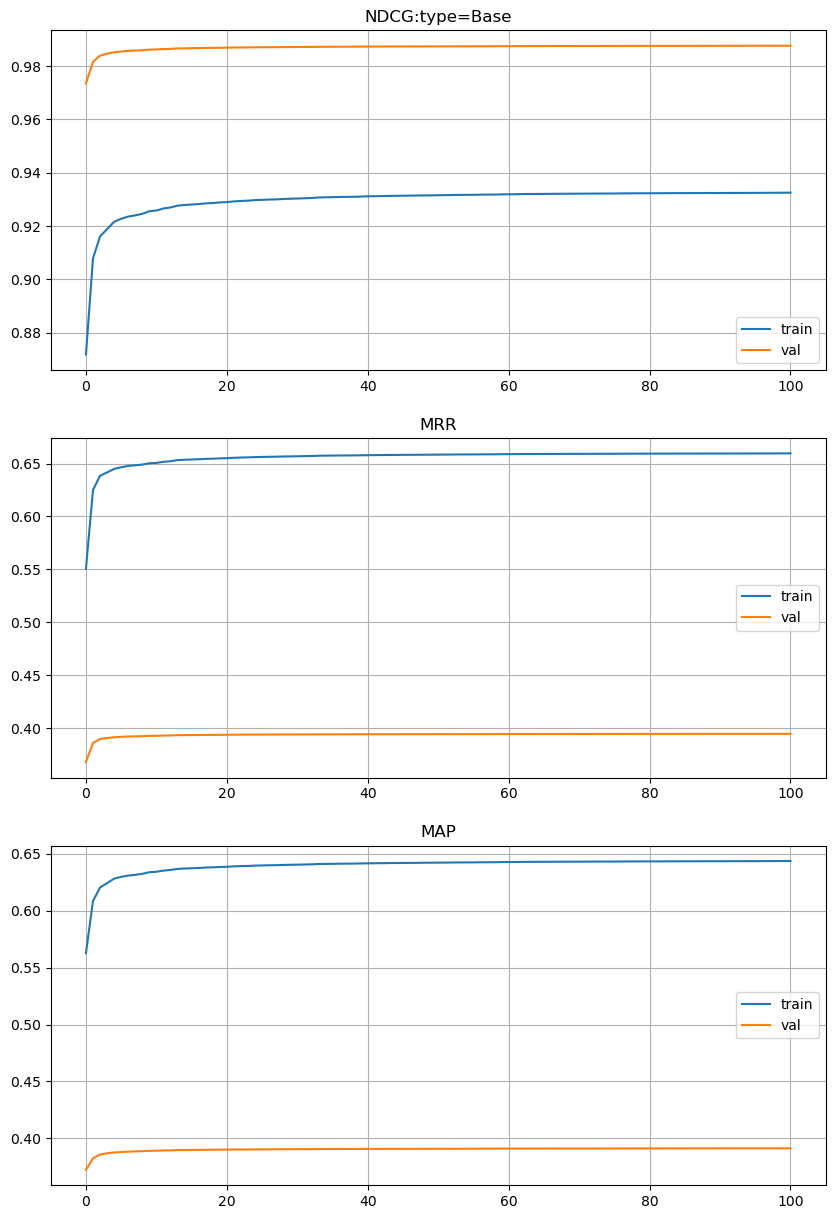

In [137]:
import matplotlib.pyplot as plt


cb_eval_resuls = model.get_evals_result()
metrics = cb_eval_resuls["learn"].keys()

fig, axs = plt.subplots(len(metrics), 1)
fig.set_figheight(15)
fig.set_figwidth(10)

for i, metric_name in enumerate(metrics):
    axs[i].plot(cb_eval_resuls["learn"][metric_name], label="train")
    axs[i].plot(cb_eval_resuls["validation"][metric_name], label="val")
    axs[i].grid()
    axs[i].set_title(metric_name)
    axs[i].legend()

plt.show()

In [138]:
feature_importance = {
    'PredictionValuesChange': model.get_feature_importance(type='PredictionValuesChange'),
    # 'LossFunctionChange': model.get_feature_importance(type='LossFunctionChange'),
    # 'FeatureImportance': model.get_feature_importance()
}

# Create a nice DataFrame to view them
importance_df = pl.DataFrame({
    'feature': feature_cols,
    'PredictionValuesChange': feature_importance['PredictionValuesChange'],
    # 'LossFunctionChange': feature_importance['LossFunctionChange'],
    # 'FeatureImportance': feature_importance['FeatureImportance']
})
print(importance_df)

shape: (4, 2)
┌───────────────────────┬────────────────────────┐
│ feature               ┆ PredictionValuesChange │
│ ---                   ┆ ---                    │
│ str                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ user_counter_upvote   ┆ 3.836102               │
│ user_counter_downvote ┆ 8.882807               │
│ item_counter_upvote   ┆ 60.63083               │
│ item_counter_downvote ┆ 26.650262              │
└───────────────────────┴────────────────────────┘


Processing trees...
128/496 trees processed	passed time: 12ms	remaining time: 34.4ms
256/496 trees processed	passed time: 22.3ms	remaining time: 20.9ms
384/496 trees processed	passed time: 31.1ms	remaining time: 9.08ms
496/496 trees processed	passed time: 39.2ms	remaining time: 0us
Processing documents...
128/7982476 documents processed	passed time: 1.46ms	remaining time: 1m 31s
256/7982476 documents processed	passed time: 2.6ms	remaining time: 1m 21s
384/7982476 documents processed	passed time: 3.75ms	remaining time: 1m 17s
512/7982476 documents processed	passed time: 4.89ms	remaining time: 1m 16s
640/7982476 documents processed	passed time: 6.02ms	remaining time: 1m 15s
768/7982476 documents processed	passed time: 7.19ms	remaining time: 1m 14s
896/7982476 documents processed	passed time: 8.26ms	remaining time: 1m 13s
1024/7982476 documents processed	passed time: 9.42ms	remaining time: 1m 13s
1152/7982476 documents processed	passed time: 10.5ms	remaining time: 1m 12s
1280/7982476 docu

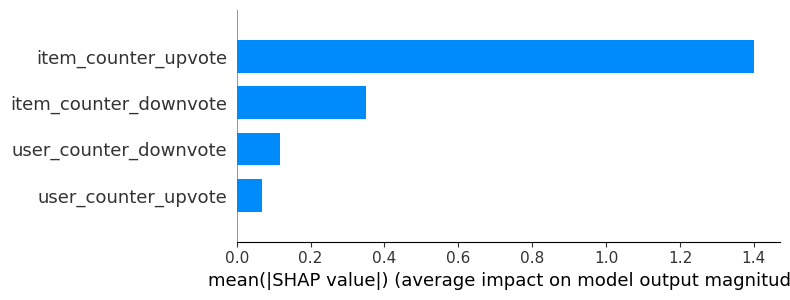

In [139]:
import shap

shap_values = model.get_feature_importance(
    valid_pool, 
    type='ShapValues',
    verbose=100
)

# Remove the bias term (last column) and convert to numpy
shap_values = shap_values[:, :-1]

shap.summary_plot(
    shap_values,
    valid_pool.get_features(), 
    feature_names=feature_cols,
    plot_type='bar'
)

### 6*. Logging CatBoost with MLFlow

Documentation: 
https://mlflow.org/docs/latest/api_reference/python_api/mlflow.catboost.html

Default metric period is 5 because PFound, MAP, NDCG, MRR is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MRR is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.8718036	test: 0.9734291	best: 0.9734291 (0)	total: 1.96s	remaining: 1m 36s
1:	total: 2.25s	remaining: 53.9s
2:	total: 2.53s	remaining: 39.6s
3:	total: 2.81s	remaining: 32.4s
4:	total: 3.1s	remaining: 27.9s
5:	learn: 0.9078729	test: 0.9815757	best: 0.9815757 (5)	total: 4.03s	remaining: 29.5s
6:	total: 4.31s	remaining: 26.5s
7:	total: 4.59s	remaining: 24.1s
8:	total: 4.88s	remaining: 22.2s
9:	total: 5.16s	remaining: 20.6s
10:	learn: 0.9161089	test: 0.9838737	best: 0.9838737 (10)	total: 6.09s	remaining: 21.6s
11:	total: 6.37s	remaining: 20.2s
12:	total: 6.66s	remaining: 18.9s
13:	total: 6.94s	remaining: 17.8s
14:	total: 7.22s	remaining: 16.8s
15:	learn: 0.9188427	test: 0.9846400	best: 0.9846400 (15)	total: 8.16s	remaining: 17.3s
16:	total: 8.44s	remaining: 16.4s
17:	total: 8.72s	remaining: 15.5s
18:	total: 9.01s	remaining: 14.7s
19:	total: 9.29s	remaining: 13.9s
20:	learn: 0.9215808	test: 0.9851291	best: 0.9851291 (20)	total: 10.2s	remaining: 14.1s
21:	total: 10.5s	remaining: 

2025/04/15 20:32:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run enthused-eel-505 at: http://127.0.0.1:5000/#/experiments/728391030308540449/runs/b1b084915a6e4f9c964af79fc9b77876
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/728391030308540449


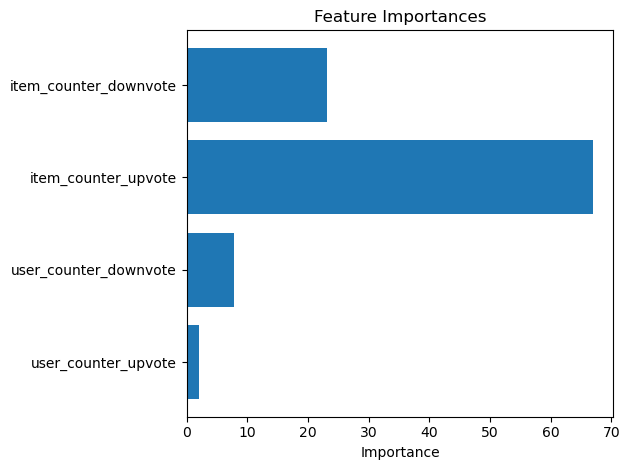

In [140]:
import mlflow
import mlflow.catboost


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("catboost_ranking_experiment")

with mlflow.start_run():
    model = CatBoostRanker(
        iterations=50,
        learning_rate=0.1,
        depth=6,
        task_type="GPU",
        devices='0-1',
        loss_function='YetiRank',
        eval_metric="NDCG:hints=skip_train~false",
        custom_metric=[
            'MAP:hints=skip_train~false',
            'MRR:hints=skip_train~false'
        ],
        verbose=100,
        random_seed=42,
    )

    mlflow.log_params(model.get_params())

    model.fit(train_pool, eval_set=valid_pool, use_best_model=True, verbose=True)

    mlflow.catboost.log_model(model, artifact_path="model")

    feature_importances = model.get_feature_importance(type='PredictionValuesChange')
    plt.barh(feature_cols, feature_importances)
    plt.xlabel("Importance")
    plt.title("Feature Importances")
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    mlflow.log_artifact("feature_importance.png")

    eval_result = model.eval_metrics(valid_pool, metrics=['NDCG', 'MAP', 'MRR'])
    for i in range(len(eval_result["NDCG:type=Base"])):
        mlflow.log_metric("NDCG", eval_result['NDCG:type=Base'][i], step=i)
        mlflow.log_metric("MAP", eval_result['MAP'][i], step=i)
        mlflow.log_metric("MRR", eval_result['MRR'][i], step=i)